# Real Time Predistortions
This tutorial demonstrates the use of real time predistortions feature available on a Qblox QCM.
Please familiarize yourself with the feature by going through our user guide on [Real Time Predistortions](https://docs.qblox.com/en/main/cluster/real_time_predistortions.html).

## Setup
First, we are going to import the required packages.

In [1]:
from __future__ import annotations

from typing import TYPE_CHECKING, Callable

import matplotlib.pyplot as plt
import numpy as np
from qcodes.instrument import find_or_create_instrument
from scipy.optimize import curve_fit

from qblox_instruments import Cluster, ClusterType

if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module

### Scan For Clusters

We scan for the available devices connected via ethernet using the Plug & Play functionality of the Qblox Instruments package (see [Plug & Play](https://docs.qblox.com/en/main/api_reference/tools.html#api-pnp) for more info).

In [4]:
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.1 with name "cluster-mm" and serial number 00015_2251_003


In [5]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"

### Connect to Cluster

We now make a connection with the Cluster.

In [6]:
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
            8: ClusterType.CLUSTER_QRM_RF,
        }
        if cluster_ip is None
        else None
    ),
)

#### Get connected modules

In [8]:
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }

In [9]:
# QCM baseband modules
modules = get_connected_modules(cluster, lambda mod: mod.is_qcm_type and not mod.is_rf_type)
modules

{2: <Module: cluster0_module2 of Cluster: cluster0>}

In [10]:
module = modules[2]

In [14]:
print(module.is_qcm_type, module.is_rf_type)

True False


In [7]:
cluster.led_brightness('medium')

### Reset the Cluster

We reset the Cluster to enter a well-defined state. Note that resetting will clear all stored parameters, so resetting between experiments is usually not desirable.

In [7]:
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


### Upload a sequence

Note that we are using a sequence that plays a square pulse once and uses no waveform memory, only voltage offsets.

In [ ]:
# Sequence program.
seq_prog = f"""
set_mrk       {0b1111}          #Set all marker outputs to 1.    hexidecimal for 15
set_awg_offs  1638, 1638        #Set the offset of the AWG to about 0.3 of the max.
upd_param     1000              #Update parameters and wait 1 us.
set_mrk       {0b0000}          #Set all marker outputs to 0.    hexidecimal for 0
set_awg_offs  0, 0              #Set the offset of the AWG to zero.
upd_param     1000              #Update parameters and wait 1 us.
stop                            #Stop the sequence.
"""

# Add sequence to single dictionary and write to JSON file.
sequence = {
    "waveforms": {},
    "weights": {},
    "acquisitions": {},
    "program": seq_prog,
}
module.sequencer0.sequence(sequence)
module.disconnect_outputs()
module.sequencer0.connect_sequencer("out0_1")

Now let's start the sequence. If you want to observe the sequence, this is the time to connect an oscilloscope to marker output 1 and one or more
of the four outputs. Configure the oscilloscope to trigger a *single* time on the marker output 1.

In [9]:
# Arm and start both sequencers.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of both sequencers.
print(module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


The following is data acquired from a scope.

<img src="./rtp_figs/before_rtp.svg" alt="drawing" width="50%"/>

## Apply Predistortions
Each output of a QCM module has the following filters:

1. 4 x Exponential overshoot filter
    This filter corrects for an exponential overshoot or undershoot.
    It is characterized by two coefficients, the time constant and the relative amplitude of the overshoot/undershoot.

2. 1 x FIR filter
    This filter may be used to correct for arbitrary distortions.
    It provides 32 configurable coefficients corresponding to 32 ns.

Each of the above filters can be in one of three states in a QCM:

1. `enabled`: The filter is enabled. Note that the playback is delayed in this case.

2. `bypassed`: The filter is disabled.

3. `delay_comp`: The filter is disabled but is delayed as if it were enabled.

In a QRM, QCM-RF or QRM-RF there are no filters, and so the `enabled` mode doesn't exist.

### Exponential overshoot filter

In the scope data shown previously, if we zoom in to the maximum value of the square pulse, we see that there is an exponential overshoot.
The fit shows the same, characterized by a relative amplitude and a time constant which we can use to correct the overshoot.

The fit function used is:
$$ f(t) =
\begin{cases}
A_p(1 + Ae^{-t/\tau}) \text{ if } t > 0\\ % # noqa: ERA001
0 \text{ if } t < 0
\end{cases}$$
where,

$A_p$ is the pulse amplitude

$A$ is the amplitude of the exponential overshoot

$\tau$ is the time constant of the exponential overshoot

<img src="./rtp_figs/before_rtp_zoom.svg" alt="drawing" width="50%"/>


In [10]:
module.out0_exp0_time_constant(2019)  # ~2 us time constant
module.out0_exp0_amplitude(0.01044)  # relative amplitude of 0.01
# Note that a negative amplitude corrects for an undershoot.
module.out0_exp0_config("enabled")  # enable the exponential overshoot correction

In [11]:
# Arm and start both sequencers.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of both sequencers.
print(module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


The following is data acquired after correction with one exponential overshoot filter.

<img src="./rtp_figs/after_one_exp.svg" alt="drawing" width="50%"/>

In [12]:
module.out0_exp1_time_constant(313)  # 313 ns time constant
module.out0_exp1_amplitude(0.00617)  # relative amplitude of 0.006
# Note that a negative amplitude corrects for an undershoot
module.out0_exp1_config("enabled")  # enable the exponential overshoot correction

In [13]:
# Arm and start both sequencers.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of both sequencers.
print(module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


The following is data acquired after correction with two exponential overshoot filters.

<img src="./rtp_figs/after_two_exp.svg" alt="drawing" width="50%"/>


### FIR filter

We can zoom in even more to see that there are short timescale distortions.
The prediction is a convolution of the data using a best fit of 32 FIR coefficients.

<img src="./rtp_figs/after_two_exp_zoom.svg" alt="drawing" width="50%"/>

In [14]:
module.out0_fir_coeffs(
    [  # 32 FIR coefficients (corresponding to 32 samples or ns)
        # may be used. Each with a range of [-2,2).
        7.48915982e-01,
        9.69579219e-02,
        9.52478332e-02,
        9.81260837e-02,
        -3.27428212e-02,
        6.12058070e-03,
        -1.29196458e-02,
        6.58390575e-03,
        -3.33153314e-03,
        -3.51480767e-03,
        9.60311013e-04,
        -2.87579262e-03,
        6.52713771e-03,
        -2.56164552e-03,
        -3.57635616e-04,
        6.04179726e-04,
        -1.12007036e-03,
        6.47927968e-04,
        -7.30273082e-04,
        1.47880116e-04,
        8.68155082e-05,
        -3.04216668e-04,
        -2.92916380e-04,
        4.34019812e-04,
        -8.44964139e-04,
        8.17907868e-04,
        -8.49444212e-04,
        7.95641409e-04,
        6.26446369e-05,
        -6.65652499e-04,
        1.23404188e-03,
        -1.01509375e-03,
    ]
)
module.out0_fir_config("enabled")  # enable the exponential overshoot correction

In [15]:
# Arm and start both sequencers.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of both sequencers.
print(module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


Here is the scope acquisition after the FIR coefficients are applied to the device.

<img src="./rtp_figs/after_fir.svg" alt="drawing" width="50%"/>

## Filter latency

Looking at output 2 on the scope we see that the distortion corrected pulse is delayed.

<img src="./rtp_figs/nd_9.svg" alt="drawing" width="50%"/>

Note that the two pulses have been plotted with offsets to make them both visible.

We can also get the delay caused by the filters using `module.out{x}_latency()`.

In [16]:
print(module.out0_latency(), module.out1_latency())  # Compare latencies of the two outputs

2.4e-07 0.0


### Delay compensation
In order to have the two outputs be synchronized in time, we can enable delay compensation on output 2 for the 3 filters that we enabled.

**Note**: Using delay compensation increases the output path latency, and so also increases the time of flight. This means you may haev to adjust your acquisition delay accordingly.

In [17]:
module.out1_exp0_config(
    "delay_comp"
)  # enable delay compensation on output 2 for the exponential overshoot correction 0
module.out1_exp1_config(
    "delay_comp"
)  # enable delay compensation on output 2 for the exponential overshoot correction 1
module.out1_fir_config("delay_comp")  # enable delay compensation on output 2 for the FIR filter

In [18]:
# Arm and start both sequencers.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of both sequencers.
print(module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


After delay compensation, here are the two waveforms.

<img src="./rtp_figs/nd_10.svg" alt="drawing" width="50%"/>

## Marker and non-QCM outputs

All marker channels on the Cluster and outputs that do not belong to a QCM (i.e. QRM, QCM-RF and QRM-RF outputs), do not have predistortion filters. However, they might need to be synchronized with QCM outputs.

To do this on a non-QCM output, you may use the same function as in a QCM output, i.e. `module.out{x}_exp0_config("delay_comp")`.
To do this on a marker output, you may use the `module.marker{x}_exp0_config("delay_comp")`.

For the above example, to ensure that pulses from output 1 of a QCM-RF in slot 6 and marker 3 of the QCM coincide with output from QCM, use the following:

In [19]:
cluster.module4.out0_exp0_config(
    "delay_comp"
)  # enable delay compensation on output 1 for the exponential overshoot correction 0
cluster.module4.out0_exp1_config(
    "delay_comp"
)  # enable delay compensation on output 1 for the exponential overshoot correction 1
cluster.module4.out0_exp2_config(
    "delay_comp"
)  # enable delay compensation on output 1 for the exponential overshoot correction 2
cluster.module4.out0_fir_config(
    "delay_comp"
)  # enable delay compensation on output 1 for the FIR filter

module.marker2_exp0_config(
    "delay_comp"
)  # enable delay compensation on marker 3 for the exponential overshoot correction 0
module.marker2_exp1_config(
    "delay_comp"
)  # enable delay compensation on marker 3 for the exponential overshoot correction 1
module.marker2_exp2_config(
    "delay_comp"
)  # enable delay compensation on marker 3 for the exponential overshoot correction 2
module.marker2_fir_config("delay_comp")  # enable delay compensation on marker 3 for the FIR filter

In [20]:
# Arm and start both sequencers.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of both sequencers.
print(module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


## Simulator Functions

The filters mentioned above may be simulated using functions from `qblox_instruments.simulations.predistortions`. The functions listed here allow you to predict the behaviour of the filters given the coefficients that are applied to them, and can be used to determine the correct coefficients.

This can be done by measuring the impulse response $h$ of the path to the DUT perhaps using an oscilloscope, or a technique that is specific to your system (like the Cryoscope). The impulse response can then be inverted to get $h_{inv}$.  The simulation functions can then be used to validate these filter coefficients and, together with an iterative optimization scheme, to find the values that best match the inverse impulse response.

We demonstrate the utility of these functions through a straightforward example where we apply the simulator function to visualize the effects of a filter designed to correct for exponential overshoot. We follow these steps:

1. Play a square waveform as done in the previous sections without applying any predistortions.
2. Obtain the waveform samples from the oscilloscope (or any equivalent measurement device such as a Cluster QRM).
3. Fit the waveform for an exponential overshoot/undershoot to the form $f(t) =A_p(1 + Ae^{-t/\tau})$ and thereby obtain the filter coefficients $AA_p$ and $\tau$.
4. Pass these filter coefficients and the waveform samples obtain to the simulator function to see the corrected waveform as seen by the measurement device (oscilloscope/QRM).

### Plotting the Obtained Samples

In [21]:
# Define t(time samples) and waveform_captured
# Here we use a simulated trace
def func(x: np.ndarray, a_p: float, a: float, tau: float) -> np.ndarray:
    return a_p * (1 + a * np.exp(-x / tau))


t = np.arange(1000)
noise = np.random.normal(0, 2e-4, size=(t.size,))
waveform_captured = func(t, a_p=9.4e-2, a=-3.5e-2, tau=200) + noise

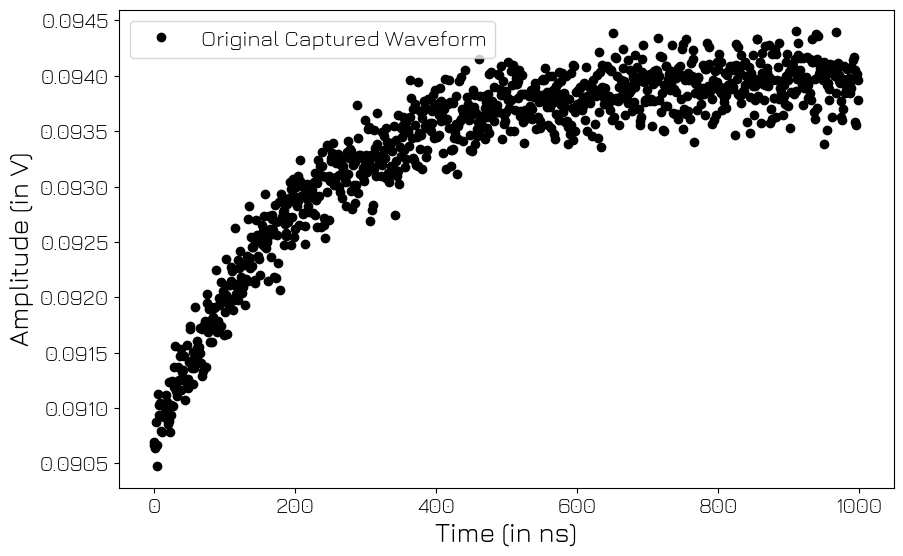

In [22]:
plt.figure()
plt.plot(t, waveform_captured, "ko", label="Original Captured Waveform")
plt.xlabel("Time (in ns)")
plt.ylabel("Amplitude (in V)")
plt.legend()
plt.show()

We can see that there is an exponential undershoot as captured by the oscilloscope. We will now try to fit these samples to the form $ f(t) =A_p(1 + Ae^{-t/\tau})$ using the `scipy.optimize.curve_fit` module.

### Curve Fitting to an Exponential Function

In [23]:

# Fit curve using initial guess p0
popt, pcov = curve_fit(func, t, waveform_captured, p0=(1, 0.4, 400))

print(f"a_p, a, tau are : {popt}")

a_p, a, tau are : [ 9.39935555e-02 -3.49960219e-02  2.00412261e+02]


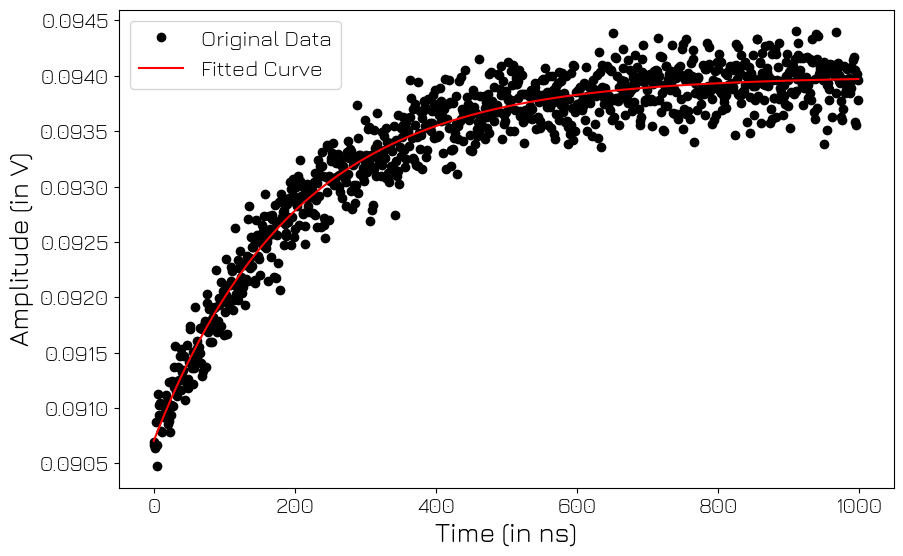

In [24]:
plt.figure()
plt.plot(t, waveform_captured, "ko", label="Original Data")
plt.plot(t, func(t, *popt), "r-", label="Fitted Curve")
plt.xlabel("Time (in ns)")
plt.ylabel("Amplitude (in V)")
plt.legend()
plt.show()

The `a` and `tau` values correspond to the $A$ and $\tau$ filter coefficients for the exponential overshoot filter.

### Simulate the Corrections

We now import the utility functions from the qblox-instruments driver and pass these filter coefficients to validate the distortion corrections.

In [25]:
from qblox_instruments.simulations.predistortions import exponential_overshoot_correction

In [26]:
amp = popt[1]
tau = popt[2]

# Pass the captured waveform and filter coefficients to the simulator functions
corrected_waveform = exponential_overshoot_correction(sig=waveform_captured, amp=amp, tau=tau)

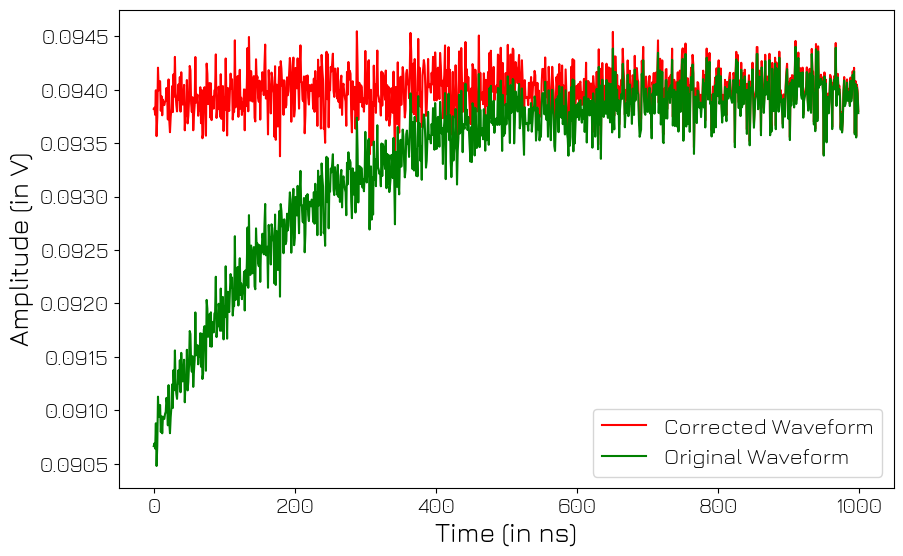

In [27]:
plt.figure()
plt.plot(t, corrected_waveform, "r-", label="Corrected Waveform")
plt.plot(t, waveform_captured, "g-", label="Original Waveform")
plt.xlabel("Time (in ns)")
plt.ylabel("Amplitude (in V)")
plt.legend()
plt.show()

**PLEASE NOTE** : The argument `sig` of the simulator function takes in waveform samples only at 1 GSPS (1 Gigasample per second) owing to the sampling rate of the Digital-to-Analog converters present in the Cluster QCM modules.

Following the procedure above, you can also simulate the behaviour for FIR coefficients using `qblox_instruments.simulations.predistortions.fir_correction`.

## Things to note:

When the filters are enabled, they are applied on a continuous data stream.
When filter parameters are changed, the sequencer is force stopped, and the data stream is changed to all zeros.
This means that when changing filter parameters, there might be transient effects.
These can be avoided by stopping the sequencer connected to the output before changing the filter parameters.
All active sequencers of a certain can be stopped using `module.stop_sequencer()`